# Access 4DMED-SEA Primary Production
    * Original Data Source: https://4dmed.artov.ismar.cnr.it/thredds/catalog/4dmed/catalog_PP.html
    * Reference:  https://4dmed.artov.ismar.cnr.it/thredds/catalog/4dmed/catalog_PP.html
    * OSC entry: https://opensciencedata.esa.int/products/4dmed-3d-prim-prod-150/collection
    * License: CC-BY-4.0

In [1]:
import xarray as xr 

zarr_href = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/4dmed-pp.zarr'

In [3]:
ds = xr.open_zarr(zarr_href)
ds

<xarray.Dataset> Size: 548GB
Dimensions:  (time: 2405, lat: 378, lon: 1012, depth: 148)
Coordinates:
  * time     (time) datetime64[ns] 19kB 2016-01-01 2016-01-02 ... 2022-08-01
  * lat      (lat) float32 2kB 30.27 30.31 30.35 30.4 ... 45.85 45.9 45.94 45.98
  * lon      (lon) float32 4kB -6.062 -6.021 -5.979 -5.937 ... 35.98 36.02 36.06
  * depth    (depth) float32 592B -3.0 -4.0 -5.0 -6.0 ... -148.0 -149.0 -150.0
Data variables:
    PP       (time, lat, lon, depth) float32 545GB dask.array<chunksize=(7, 378, 1012, 25), meta=np.ndarray>
    ZEU      (time, lat, lon) float32 4GB dask.array<chunksize=(7, 378, 1012), meta=np.ndarray>
Attributes: (12/16)
    Conventions:            CF-1.7
    title:                  Primary Production field estimated from chlorophy...
    references:              
    institution:            CNR
    project:                ESA 4DMED-Sea Project
    project_url:            http://ricerca.ismar.cnr.it/4DMED/index.html
    ...                     ...
    grid_resolution:        0.0416 degrees
    software_version:       4D MED Processor V1.0
    westernmost_longitude:  -6.062498
    easternmost_longitude:  36.0625
    southernmost_latitude:  30.270834
    northernmost_latitude:  45.979168

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------------
# Settings
# -----------------------------
date = "2020-06-15"

# Depth coordinates in your dataset are negative
depths = [-10, -50, -100]   # metres

# -----------------------------
# Select data
# -----------------------------
pp = ds["PP"].sel(
    time=date,
    method="nearest"
)

# Select nearest available depths
pp_depths = [
    pp.sel(depth=d, method="nearest")
    for d in depths
]

# Load only these three 2-D slices into memory
pp_depths = [x.compute() for x in pp_depths]

# Actual date selected
actual_date = np.datetime_as_string(
    pp_depths[0].time.values,
    unit="D"
)

# Using the same scale makes the depths directly comparable
vmin = min(float(x.min(skipna=True)) for x in pp_depths)
vmax = max(float(x.max(skipna=True)) for x in pp_depths)


/home/krasen/ocean_hackathon/.pixi/envs/default/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


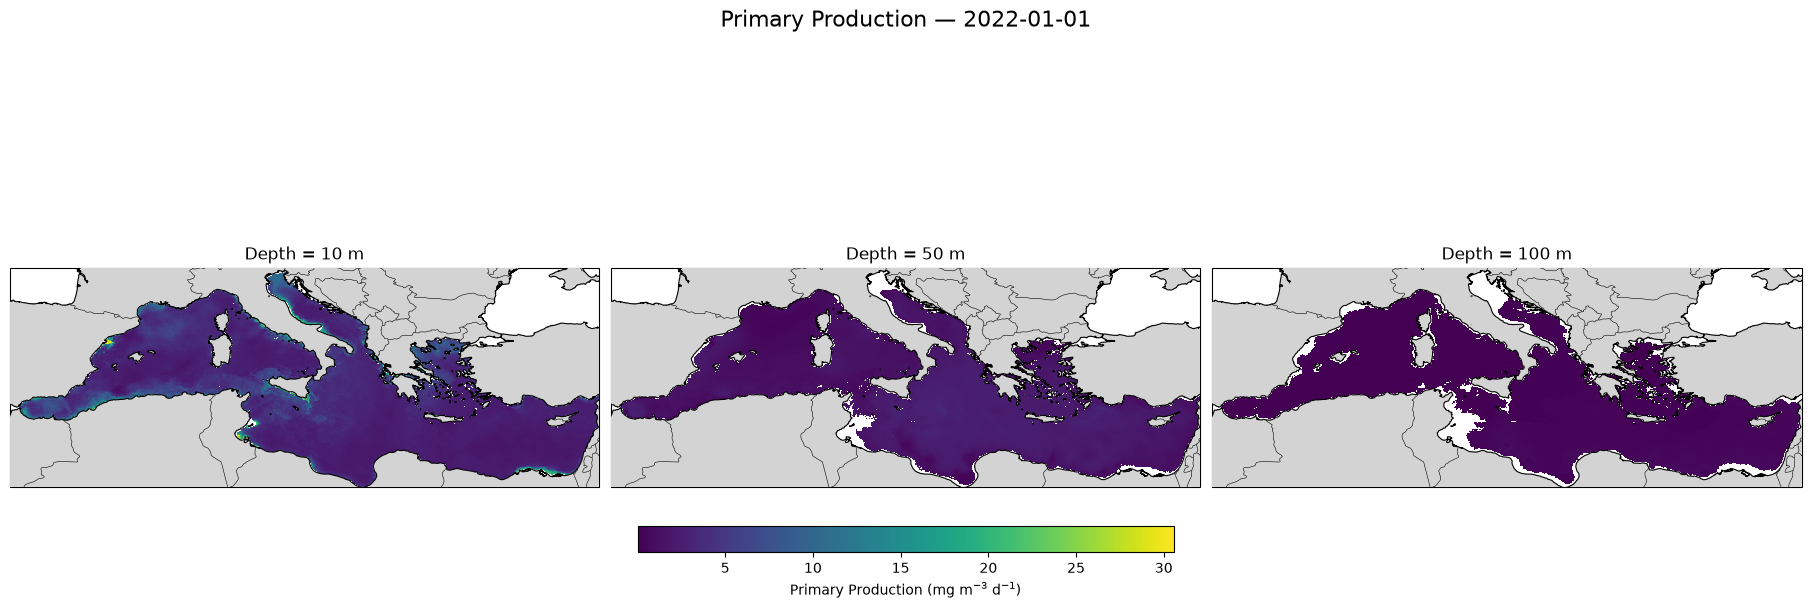

In [5]:


fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

for ax, data, requested_depth in zip(
    axes,
    pp_depths,
    depths
):
    actual_depth = float(data.depth.values)

    pcm = ax.pcolormesh(
        ds["lon"],
        ds["lat"],
        data,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax
    )

    # Basemap
    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        zorder=10
    )

    ax.coastlines(
        resolution="10m",
        linewidth=0.8,
        zorder=11
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.4,
        zorder=11
    )

    # Mediterranean extent from dataset
    ax.set_extent(
        [
            float(ds.lon.min()),
            float(ds.lon.max()),
            float(ds.lat.min()),
            float(ds.lat.max())
        ],
        crs=ccrs.PlateCarree()
    )
    
    ax.set_title(
        f"Depth = {abs(actual_depth):.0f} m"
    )

cbar = fig.colorbar(
    pcm,
    ax=axes,
    orientation="horizontal",
    fraction=0.06,
    pad=0.08
)

cbar.set_label(
    r"Primary Production (mg m$^{-3}$ d$^{-1}$)"
)

fig.suptitle(
    f"Primary Production — {actual_date}",
    fontsize=16
)

plt.show()